# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [4]:
!pip install nltk contractions rank_bm25 --quiet

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.0 MB/s eta 0:00:00
Done.


In [ ]:
import json
import os
TRAIN_PATH    = 'train-claims.json'
DEV_PATH      = 'dev-claims.json'
TEST_PATH     = 'test-claims-unlabelled.json'
EVIDENCE_PATH = 'evidence.json'

OUTPUT_DIR    = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Confirm files exist
for name, path in [
    ('train-claims',         TRAIN_PATH),
    ('dev-claims',           DEV_PATH),
    ('test-claims',          TEST_PATH),
    ('evidence',             EVIDENCE_PATH),
]:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {name}')

# Load all files
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

print('\nLoading train-claims...')
train_claims = load_json(TRAIN_PATH)

print('Loading dev-claims...')
dev_claims = load_json(DEV_PATH)

print('Loading test-claims...')
test_claims = load_json(TEST_PATH)

print('Loading evidence (may take ~60s)...')
evidence = load_json(EVIDENCE_PATH)

print('\nAll loaded.')
print(f'  Train claims : {len(train_claims):,}')
print(f'  Dev claims   : {len(dev_claims):,}')
print(f'  Test claims  : {len(test_claims):,}')
print(f'  Evidence     : {len(evidence):,}')

  ✓  train-claims
  ✓  dev-claims
  ✓  test-claims
  ✓  evidence

Loading train-claims...
Loading dev-claims...
Loading test-claims...
Loading evidence (may take ~60s)...

All loaded.
  Train claims : 1,228
  Dev claims   : 154
  Test claims  : 153
  Evidence     : 1,208,827


In [ ]:
# Check A — print one sample from each
print('=== Sample train claim ===')
sample_key = list(train_claims.keys())[0]
print(json.dumps(train_claims[sample_key], indent=2))

print('\n=== Sample evidence passage ===')
ev_key = list(evidence.keys())[0]
print(f'{ev_key}: {evidence[ev_key]}')

# Check B — required fields
REQUIRED = {'claim_text', 'claim_label', 'evidences'}
errors = []
for cid, entry in train_claims.items():
    missing = REQUIRED - set(entry.keys())
    if missing:
        errors.append(f'{cid} missing: {missing}')
if errors:
    print(f'\n✗ {len(errors)} claims missing fields')
    for e in errors[:5]:
        print(f'  {e}')
else:
    print('\n✓ All train claims have required fields')

# Check C — evidence IDs valid
evidence_ids = set(evidence.keys())
missing_ids = 0
for cid, entry in train_claims.items():
    for eid in entry.get('evidences', []):
        if eid not in evidence_ids:
            missing_ids += 1
if missing_ids:
    print(f'✗ {missing_ids} evidence IDs not found in evidence.json')
else:
    print('✓ All evidence IDs valid')

=== Sample train claim ===
{
  "claim_text": "Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.",
  "claim_label": "DISPUTED",
  "evidences": [
    "evidence-442946",
    "evidence-1194317",
    "evidence-12171"
  ]
}

=== Sample evidence passage ===
evidence-0: John Bennet Lawes, English entrepreneur and agricultural scientist

✓ All train claims have required fields
✓ All evidence IDs valid



Train class distribution (total=1228):
  SUPPORTS            :   519  (42.3%)
  REFUTES             :   199  (16.2%)
  NOT_ENOUGH_INFO     :   386  (31.4%)
  DISPUTED            :   124  (10.1%)

Dev class distribution (total=154):
  SUPPORTS            :    68  (44.2%)
  REFUTES             :    27  (17.5%)
  NOT_ENOUGH_INFO     :    41  (26.6%)
  DISPUTED            :    18  (11.7%)


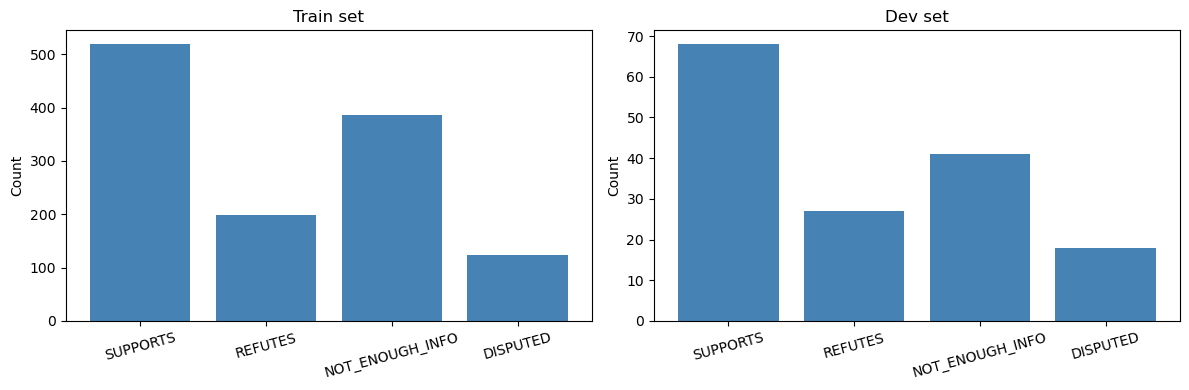


Claim length (words):
  Min    : 4
  Max    : 67
  Mean   : 20.1
  Median : 19.0

Evidence passage length distribution:
  ≤5 words       :   13,578
  6–10 words     :  180,771
  11–20 words    :  547,481
  21–50 words    :  451,498
  51–100 words   :   15,217
  100+ words     :      282

Gold evidences per claim:
  Min    : 1
  Max    : 5
  Mean   : 3.4


In [ ]:
import collections
import numpy as np
import matplotlib.pyplot as plt

# ── Class distribution ──
LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']

def class_distribution(dataset, name):
    counts = collections.Counter(
        v['claim_label'] for v in dataset.values()
    )
    total = sum(counts.values())
    print(f'\n{name} class distribution (total={total}):')
    for label in LABELS:
        n = counts.get(label, 0)
        print(f'  {label:<20}: {n:>5}  ({100*n/total:.1f}%)')
    return counts

train_counts = class_distribution(train_claims, 'Train')
dev_counts   = class_distribution(dev_claims,   'Dev')

# ── Plot class distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (counts, title) in zip(axes, [
    (train_counts, 'Train set'),
    (dev_counts,   'Dev set'),
]):
    vals = [counts.get(l, 0) for l in LABELS]
    ax.bar(LABELS, vals, color='steelblue')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

# ── Claim length distribution ──
claim_lengths = [
    len(v['claim_text'].split())
    for v in train_claims.values()
]
print(f'\nClaim length (words):')
print(f'  Min    : {np.min(claim_lengths)}')
print(f'  Max    : {np.max(claim_lengths)}')
print(f'  Mean   : {np.mean(claim_lengths):.1f}')
print(f'  Median : {np.median(claim_lengths):.1f}')

# ── Evidence length distribution ──
ev_lengths = [len(text.split()) for text in evidence.values()]
buckets = {
    '≤5 words'    : sum(1 for l in ev_lengths if l <= 5),
    '6–10 words'  : sum(1 for l in ev_lengths if 6 <= l <= 10),
    '11–20 words' : sum(1 for l in ev_lengths if 11 <= l <= 20),
    '21–50 words' : sum(1 for l in ev_lengths if 21 <= l <= 50),
    '51–100 words': sum(1 for l in ev_lengths if 51 <= l <= 100),
    '100+ words'  : sum(1 for l in ev_lengths if l > 100),
}
print('\nEvidence passage length distribution:')
for bucket, count in buckets.items():
    print(f'  {bucket:<15}: {count:>8,}')

# ── Evidences per claim ──
ev_per_claim = [
    len(v['evidences']) for v in train_claims.values()
]
print(f'\nGold evidences per claim:')
print(f'  Min    : {np.min(ev_per_claim)}')
print(f'  Max    : {np.max(ev_per_claim)}')
print(f'  Mean   : {np.mean(ev_per_claim):.1f}')

In [ ]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    # Guard against empty or non-string input
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []

    # 1. Expand contractions — wrapped in try/except
    #    because the contractions library crashes on some
    #    very short or unusual strings in the evidence corpus
    try:
        text = contractions.fix(text)
    except Exception:
        pass  # if it fails, just keep the original text

    # 2. Lowercase
    text = text.lower()

    # 3. Remove punctuation and special characters
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # 4. Tokenise
    tokens = word_tokenize(text)

    # 5. Remove stopwords
    tokens = [t for t in tokens if t not in STOPWORDS]

    # 6. Remove empty or single-character tokens
    tokens = [t for t in tokens if len(t) > 1]

    return tokens

# Test it
test_sentence = "The Earth's climate isn't changing rapidly, according to some scientists."
print('Raw    :', test_sentence)
print('Cleaned:', clean_text(test_sentence))

# Test edge cases that previously caused the crash
print('Empty  :', clean_text(''))
print('Number :', clean_text('42'))
print('Short  :', clean_text('a'))

Raw    : The Earth's climate isn't changing rapidly, according to some scientists.
Cleaned: ['earth', 'climate', 'changing', 'rapidly', 'according', 'scientists']
Empty  : []
Number : ['42']
Short  : []


In [ ]:
def clean_claims(dataset):
    cleaned = {}
    for cid, entry in dataset.items():
        cleaned[cid] = {
            **entry,
            'clean_tokens': clean_text(entry['claim_text'])
        }
    return cleaned

print('Cleaning train claims...')
train_clean = clean_claims(train_claims)

print('Cleaning dev claims...')
dev_clean = clean_claims(dev_claims)

print('Cleaning test claims...')
test_clean = clean_claims(test_claims)

# Verify
sample = list(train_clean.values())[0]
print('\nSample:')
print('  Raw    :', sample['claim_text'])
print('  Tokens :', sample['clean_tokens'])

Cleaning train claims...
Cleaning dev claims...
Cleaning test claims...

Sample:
  Raw    : Not only is there no scientific evidence that CO2 is a pollutant, higher CO2 concentrations actually help ecosystems support more plant and animal life.
  Tokens : ['scientific', 'evidence', 'co2', 'pollutant', 'higher', 'co2', 'concentrations', 'actually', 'help', 'ecosystems', 'support', 'plant', 'animal', 'life']


In [ ]:
evidence_clean = {}

total = len(evidence)
for i, (eid, text) in enumerate(evidence.items()):
    evidence_clean[eid] = clean_text(text)
    if (i + 1) % 200000 == 0:
        print(f'  Processed {i+1:,} / {total:,}')

print(f'Done. Total cleaned: {len(evidence_clean):,}')

# Verify
sample_eid = list(evidence.keys())[0]
print('\nSample:')
print('  Raw    :', evidence[sample_eid])
print('  Tokens :', evidence_clean[sample_eid])

  Processed 200,000 / 1,208,827
  Processed 400,000 / 1,208,827
  Processed 600,000 / 1,208,827
  Processed 800,000 / 1,208,827
  Processed 1,000,000 / 1,208,827
  Processed 1,200,000 / 1,208,827
Done. Total cleaned: 1,208,827

Sample:
  Raw    : John Bennet Lawes, English entrepreneur and agricultural scientist
  Tokens : ['john', 'bennet', 'lawes', 'english', 'entrepreneur', 'agricultural', 'scientist']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

LABEL2ID = {
    'SUPPORTS': 0, 'REFUTES': 1,
    'NOT_ENOUGH_INFO': 2, 'DISPUTED': 3
}

def build_input(claim_entry):
    # Combine claim text + all gold evidence texts into one string
    claim_text = claim_entry['claim_text']
    gold_ev_texts = [
        evidence.get(eid, '') for eid in claim_entry.get('evidences', [])
    ]
    return claim_text + ' ' + ' '.join(gold_ev_texts)

# Build train inputs
train_texts  = [build_input(v) for v in train_claims.values()]
train_labels = [LABEL2ID[v['claim_label']] for v in train_claims.values()]

# Build dev inputs
dev_texts  = [build_input(v) for v in dev_claims.values()]
dev_labels = [LABEL2ID[v['claim_label']] for v in dev_claims.values()]

# TF-IDF vectorise + logistic regression
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_texts)
X_dev   = vectorizer.transform(dev_texts)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, train_labels)

oracle_acc = accuracy_score(dev_labels, clf.predict(X_dev))
print(f'Oracle accuracy (gold evidence → dev): {oracle_acc:.4f}')
print('This is the classification ceiling.')
print('If final system is far below this, the bottleneck is retrieval.')

Oracle accuracy (gold evidence → dev): 0.5000
This is the classification ceiling.
If final system is far below this, the bottleneck is retrieval.


In [ ]:
def save_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False)
    print(f'  Saved: {path}')

# Save cleaned claims (tokens added as new field)
save_json(train_clean, os.path.join(OUTPUT_DIR, 'train_clean.json'))
save_json(dev_clean,   os.path.join(OUTPUT_DIR, 'dev_clean.json'))
save_json(test_clean,  os.path.join(OUTPUT_DIR, 'test_clean.json'))

# Save cleaned evidence tokens
save_json(evidence_clean, os.path.join(OUTPUT_DIR, 'evidence_clean.json'))

# Save a summary of key stats
summary = {
    'train_count'     : len(train_claims),
    'dev_count'       : len(dev_claims),
    'test_count'      : len(test_claims),
    'evidence_count'  : len(evidence),
    'train_class_dist': dict(train_counts),
    'dev_class_dist'  : dict(dev_counts),
    'oracle_accuracy' : round(oracle_acc, 4),
    'mean_claim_length'      : round(float(np.mean(claim_lengths)), 1),
    'mean_evidences_per_claim': round(float(np.mean(ev_per_claim)), 1),
    'evidence_length_buckets' : buckets,
}
save_json(summary, os.path.join(OUTPUT_DIR, 'stats_summary.json'))

print('\nAll outputs saved to:', OUTPUT_DIR)
print('\nTell your teammates:')
print('  BM25 retrieval  → load evidence_clean.json (tokens)')
print('  Transformer     → load original evidence.json (raw text)')

  Saved: preprocessed/train_clean.json
  Saved: preprocessed/dev_clean.json
  Saved: preprocessed/test_clean.json
  Saved: preprocessed/evidence_clean.json
  Saved: preprocessed/stats_summary.json

All outputs saved to: preprocessed

Tell your teammates:
  BM25 retrieval  → load evidence_clean.json (tokens)
  Transformer     → load original evidence.json (raw text)


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [6]:
import json
import numpy as np
from rank_bm25 import BM25Okapi

EVIDENCE_CLEAN_PATH = 'evidence_clean.json'
DEV_CLEAN_PATH = 'dev_clean.json'
DEV_RAW_PATH = 'dev-claims.json'

with open(EVIDENCE_CLEAN_PATH, 'r', encoding='utf-8') as f:
  evidence_clean = json.load(f)
evidence_ids = list(evidence_clean.keys())
tokenized_corpus = list(evidence_clean.values())
with open(DEV_CLEAN_PATH, 'r', encoding='utf-8') as f:
  dev_claims_clean = json.load(f)
with open(DEV_RAW_PATH, 'r', encoding='utf-8') as f:
  dev_claims_raw = json.load(f)
dev_claims_subset = dict(list(dev_claims_clean.items())[:30])

In [7]:
def evaluate_retrieval(predictions, ground_truth):
  true_positives = 0
  retrieved_count = 0
  relevant_count = 0

  for claim_id, pred_data in predictions.items():
    pred_evidences = set(pred_data['evidences'])
    actual_evidences = set(ground_truth[claim_id].get('evidences', []))

    true_positives += len(pred_evidences.intersection(actual_evidences))
    retrieved_count += len(pred_evidences)
    relevant_count += len(actual_evidences)

  precision = true_positives / retrieved_count if retrieved_count > 0 else 0
  recall = true_positives / relevant_count if relevant_count > 0 else 0
  f_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

  return precision, recall, f_score

# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [8]:
TOP_K = 5
best_f1 = 0
best_params = {}
k1_range = [0.5, 0.8, 1.2, 1.5]
b_range = [0.6, 0.75, 0.85, 0.9]
for k1_val in k1_range:
  for b_val in b_range:
    print(f"\nTesting k1={k1_val}, b={b_val}")
    bm25_model = BM25Okapi(tokenized_corpus, k1=k1_val, b=b_val)
    predictions = {}
    for claim_id, data in dev_claims_subset.items():
      query_tokens = data['clean_tokens']
      scores = bm25_model.get_scores(query_tokens)
      top_k_indices = np.argsort(scores)[-TOP_K:][::-1]
      predictions[claim_id] = {
        "claim_label": "NOT_ENOUGH_INFO",
        "evidences": [evidence_ids[idx] for idx in top_k_indices]
      }
    precision, recall, f1 = evaluate_retrieval(predictions, dev_claims_raw)
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    if f1 > best_f1:
      best_f1 = f1
      best_params = {'k1': k1_val, 'b': b_val}
print(f"k1={best_params['k1']}, b={best_params['b']} (F1-score: {best_f1:.4f})")


Testing k1=0.5, b=0.6
Precision: 0.0933, Recall: 0.1346, F1: 0.1102

Testing k1=0.5, b=0.75


KeyboardInterrupt: 

In [13]:
# just pick the best parameter
best_params = {'k1': 0.5, 'b': 0.6}
print(f"Using k1={best_params['k1']}, b={best_params['b']}")

Using k1=0.5, b=0.6


In [ ]:
from tqdm import tqdm
bm25_model = BM25Okapi(tokenized_corpus, k1=best_params['k1'], b=best_params['b'])
TOP_K = 15
def generate_bm25_dataset(clean_file_path, output_file_path, model, top_k):
  print(f"process: {clean_file_path}")
  with open(clean_file_path, 'r', encoding='utf-8') as f:
    data_dict = json.load(f)
  predictions = {}
  file_name = clean_file_path.split('/')[-1]
  for claim_id, data in tqdm(data_dict.items(), desc=f"process {file_name}"):
    query_tokens = data['clean_tokens']
    scores = model.get_scores(query_tokens)
    top_k_indices = np.argsort(scores)[-top_k:][::-1]

    predictions[claim_id] = {
      "claim_label": "NOT_ENOUGH_INFO",
      "evidences": [evidence_ids[idx] for idx in top_k_indices]
    }

  with open(output_file_path, 'w', encoding='utf-8') as f:
        json.dump(predictions, f, indent=4)
  print(f"success: {output_file_path}")

generate_bm25_dataset(
  clean_file_path='preprocessed/dev_clean.json',
  output_file_path='bm25_dev_predictions.json',
  model=bm25_model,
  top_k=TOP_K
)

generate_bm25_dataset(
  clean_file_path='preprocessed/train_clean.json',
  output_file_path='bm25_train_predictions.json',
  model=bm25_model,
  top_k=TOP_K
)

generate_bm25_dataset(
  clean_file_path='preprocessed/test_clean.json',
  output_file_path='bm25_test_predictions.json',
  model=bm25_model,
  top_k=TOP_K
)

process: preprocessed/dev_clean.json


process dev_clean.json: 100%|██████████| 154/154 [03:14<00:00,  1.26s/it]


success: bm25_dev_predictions.json
process: preprocessed/train_clean.json


process train_clean.json: 100%|██████████| 1228/1228 [25:19<00:00,  1.24s/it]


success: bm25_train_predictions.json
process: preprocessed/test_clean.json


process test_clean.json: 100%|██████████| 153/153 [03:06<00:00,  1.22s/it]

success: bm25_test_predictions.json


In [14]:
!pip install sentence-transformers --quiet
# this is new cell for cross-encoder

from sentence_transformers import CrossEncoder
import json

reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
print("Reranker loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranker loaded.


In [ ]:
!python eval.py --predictions bm25_dev_predictions.json --groundtruth dev-claims.json

Evidence Retrieval F-score (F)    = 0.09441361871702429
Claim Classification Accuracy (A) = 0.2662337662337662
Harmonic Mean of F and A          = 0.1393942911756975


In [16]:
# Unzip the model folder
!unzip classifier_model_1.zip -d /content/
print("Model folder ready.")

Archive:  classifier_model_1.zip
   creating: /content/classifier_model_1/
  inflating: /content/__MACOSX/._classifier_model_1  
  inflating: /content/classifier_model_1/model.safetensors  
  inflating: /content/__MACOSX/classifier_model_1/._model.safetensors  
  inflating: /content/classifier_model_1/rng_state.pth  
  inflating: /content/__MACOSX/classifier_model_1/._rng_state.pth  
  inflating: /content/classifier_model_1/tokenizer_config.json  
  inflating: /content/__MACOSX/classifier_model_1/._tokenizer_config.json  
  inflating: /content/classifier_model_1/config.json  
  inflating: /content/__MACOSX/classifier_model_1/._config.json  
  inflating: /content/classifier_model_1/scheduler.pt  
  inflating: /content/__MACOSX/classifier_model_1/._scheduler.pt  
  inflating: /content/classifier_model_1/tokenizer.json  
  inflating: /content/__MACOSX/classifier_model_1/._tokenizer.json  
  inflating: /content/classifier_model_1/training_args.bin  
  inflating: /content/__MACOSX/classifie

In [17]:
from pathlib import Path

required = [
    'bm25_dev_predictions.json',
    'dev-claims.json',
    'evidence.json',
    'classifier_1.py',
    'classifier_model_1/config.json',
]

all_good = True
for f in required:
    exists = Path(f).exists()
    status = '✅' if exists else '❌ MISSING'
    print(f"{status}  {f}")
    if not exists:
        all_good = False

if all_good:
    print("\nAll files found. Ready to proceed.")
else:
    print("\nSome files are missing — fix before continuing.")

✅  bm25_dev_predictions.json
✅  dev-claims.json
✅  evidence.json
✅  classifier_1.py
✅  classifier_model_1/config.json

All files found. Ready to proceed.


In [18]:
# classifier_1.py has two hardcoded paths that need to point
# to the correct locations in your Colab environment

with open('classifier_1.py', 'r') as f:
    src = f.read()

src = src.replace(
    'Path("classifier_model_1")',
    'Path("classifier_model_1")'          # already correct if you're in PROJECT_DIR
).replace(
    'Path("data/evidence.json")',
    'Path("evidence.json")'               # evidence.json is in root, not data/
)

with open('classifier_1.py', 'w') as f:
    f.write(src)

print("Paths fixed. classifier_1.py is ready.")

Paths fixed. classifier_1.py is ready.


In [19]:
# Only needed if running in a fresh Colab session
!pip install transformers torch --quiet
print("Dependencies ready.")

Dependencies ready.


In [ ]:
import json
from pathlib import Path
from classifier_1 import predict_label   # loads the BERT model here — takes ~30 sec

# ── Load files ──────────────────────────────────────────────────────────
print("Loading files...")

with open('bm25_dev_predictions.json', 'r') as f:
    bm25_preds = json.load(f)

with open('dev-claims.json', 'r') as f:
    dev_claims = json.load(f)

print(f"  BM25 predictions loaded: {len(bm25_preds)} claims")
print(f"  Dev claims loaded:       {len(dev_claims)} claims")

# ── Run pipeline ────────────────────────────────────────────────────────
print("\nRunning pipeline...")
output = {}
errors = []

for i, (claim_id, bm25_entry) in enumerate(bm25_preds.items()):

    try:
        # Step 1: get claim text
        claim_text = dev_claims[claim_id]['claim_text']

        # Step 2: convert "evidence-112" → 112 (classifier_1 expects list[int])
        evidence_ints = [
            int(eid.replace('evidence-', ''))
            for eid in bm25_entry['evidences'][:3]   # top 3 only
        ]

        # Step 3: classify
        label = predict_label(claim_text, evidence_ints)

        # Step 4: build output (keep original string IDs for eval.py)
        output[claim_id] = {
            'claim_label': label,
            'evidences': bm25_entry['evidences']
        }

    except Exception as e:
        # Don't let one bad claim crash the whole run
        errors.append((claim_id, str(e)))
        output[claim_id] = {
            'claim_label': 'NOT_ENOUGH_INFO',   # safe fallback
            'evidences': bm25_entry['evidences']
        }

    # Progress update every 50 claims
    if (i + 1) % 50 == 0 or (i + 1) == len(bm25_preds):
        print(f"  {i+1}/{len(bm25_preds)} claims processed...")

# ── Save output ─────────────────────────────────────────────────────────
with open('dev-claims-predictions.json', 'w') as f:
    json.dump(output, f, indent=2)

print(f"\nDone. {len(output)} predictions saved to dev-claims-predictions.json")

# Label distribution — quick sanity check
from collections import Counter
dist = Counter(v['claim_label'] for v in output.values())
print("\nLabel distribution:")
for label, count in sorted(dist.items()):
    print(f"  {label:20s}: {count}")

if errors:
    print(f"\n⚠️  {len(errors)} errors occurred:")
    for claim_id, msg in errors:
        print(f"  {claim_id}: {msg}")

Loading files...
  BM25 predictions loaded: 154 claims
  Dev claims loaded:       154 claims

Running pipeline...
  50/154 claims processed...
  100/154 claims processed...
  150/154 claims processed...
  154/154 claims processed...

Done. 154 predictions saved to dev-claims-predictions.json

Label distribution:
  NOT_ENOUGH_INFO     : 3
  REFUTES             : 11
  SUPPORTS            : 140


In [20]:
import json
from pathlib import Path
from classifier_1 import predict_label
# replace existing glue code cell(the last one) (the one that loads)

# Load files
with open('bm25_dev_predictions.json', 'r') as f:
    bm25_preds = json.load(f)
with open('dev-claims.json', 'r') as f:
    dev_claims = json.load(f)
with open('evidence.json', 'r') as f:
    evidence_db = json.load(f)

print(f"Loaded {len(bm25_preds)} claims.")

output = {}
errors = []

for i, (claim_id, bm25_entry) in enumerate(bm25_preds.items()):
    try:
        claim_text = dev_claims[claim_id]['claim_text']

        # ── Reranker: score each BM25 candidate ──────────────
        bm25_evidences = bm25_entry['evidences']  # top 15 from BM25

        pairs = [
            [claim_text, evidence_db[eid]]
            for eid in bm25_evidences
            if eid in evidence_db
        ]

        scores = reranker.predict(pairs)

        ranked = sorted(
            zip(bm25_evidences, scores),
            key=lambda x: x[1],
            reverse=True
        )
        top3_ids = [eid for eid, score in ranked[:3]]

        # ── Classifier ───────────────────────────────────────
        evidence_ints = [
            int(eid.replace('evidence-', ''))
            for eid in top3_ids
        ]
        label = predict_label(claim_text, evidence_ints)

        output[claim_id] = {
            'claim_label': label,
            'evidences': top3_ids
        }

    except Exception as e:
        errors.append((claim_id, str(e)))
        output[claim_id] = {
            'claim_label': 'NOT_ENOUGH_INFO',
            'evidences': bm25_entry['evidences'][:3]
        }

    if (i + 1) % 50 == 0 or (i + 1) == len(bm25_preds):
        print(f"  {i+1}/{len(bm25_preds)} done...")

with open('dev-claims-predictions.json', 'w') as f:
    json.dump(output, f, indent=2)

print(f"\nDone. {len(output)} predictions saved.")
if errors:
    print(f"⚠️ {len(errors)} errors: {errors[:3]}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded 154 claims.
  50/154 done...
  100/154 done...
  150/154 done...
  154/154 done...

Done. 154 predictions saved.


In [22]:
!python eval.py --predictions dev-claims-predictions.json --groundtruth dev-claims.json

Evidence Retrieval F-score (F)    = 0.16787260358688932
Claim Classification Accuracy (A) = 0.42207792207792205
Harmonic Mean of F and A          = 0.24020766695959317


In [23]:
# Quick experiment — no need to rerun classifier
# just reload predictions and trim to different K values

import json
from collections import defaultdict

# Load current predictions
with open('dev-claims-predictions.json', 'r') as f:
    preds = json.load(f)

# Save trimmed versions for K = 1,2,3,4,5
for k in [1, 2, 3, 4, 5]:
    trimmed = {
        cid: {
            'claim_label': preds[cid]['claim_label'],
            'evidences': preds[cid]['evidences'][:k]
        }
        for cid in preds
    }
    with open(f'dev-predictions-top{k}.json', 'w') as f:
        json.dump(trimmed, f, indent=2)

print("Saved top-1 through top-5 files.")

Saved top-1 through top-5 files.


In [24]:
for k in [1, 2, 3, 4, 5]:
    print(f"\n--- TOP {k} ---")
    !python eval.py --predictions dev-predictions-top{k}.json --groundtruth dev-claims.json


--- TOP 1 ---
Evidence Retrieval F-score (F)    = 0.13917748917748918
Claim Classification Accuracy (A) = 0.42207792207792205
Harmonic Mean of F and A          = 0.20932981403478898

--- TOP 2 ---
Evidence Retrieval F-score (F)    = 0.17050092764378474
Claim Classification Accuracy (A) = 0.42207792207792205
Harmonic Mean of F and A          = 0.24288641852824688

--- TOP 3 ---
Evidence Retrieval F-score (F)    = 0.16787260358688932
Claim Classification Accuracy (A) = 0.42207792207792205
Harmonic Mean of F and A          = 0.24020766695959317

--- TOP 4 ---
Evidence Retrieval F-score (F)    = 0.16787260358688932
Claim Classification Accuracy (A) = 0.42207792207792205
Harmonic Mean of F and A          = 0.24020766695959317

--- TOP 5 ---
Evidence Retrieval F-score (F)    = 0.16787260358688932
Claim Classification Accuracy (A) = 0.42207792207792205
Harmonic Mean of F and A          = 0.24020766695959317


## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*